# Calculadora de Probabilidades y Distribuciones

Este notebook te permite calcular probabilidades para diferentes distribuciones.
**Instrucciones:** Modifica solo los valores en las celdas marcadas como "PARÁMETROS" y ejecuta la celda siguiente para ver los resultados.

In [5]:
# Importar librerías necesarias
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


## 1. Distribución Normal

---

Distribución Normal(μ=78.0, σ=12.0)

Densidad en x=1.5: 0.000000
P(X ≤ 1.5) = 0.000000
P(X > 1.5) = 1.000000

Valor crítico para P(X ≤ x) = 50.0: x = nan
Valor crítico para P(X > x) = -49.0: x = nan


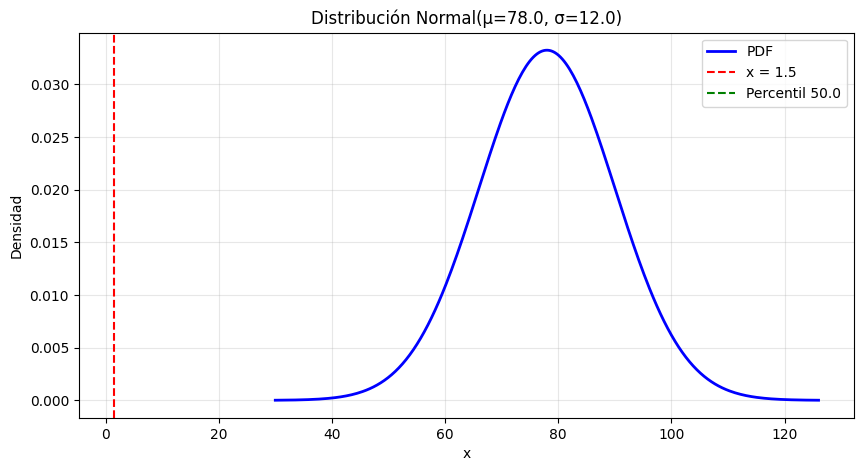

In [10]:
# ========== PARÁMETROS ==========
mu = float(input("Ingresa el valor de la media: "))
sigma = float(input("Ingresa el valor de la desviación estándar: "))
x_valor = float(input("Ingresa el valor de X: "))
p_percentil = float(input("Ingresa el percentil que deseas calcular: "))


# ========== CÁLCULOS ==========
print(f"Distribución Normal(μ={mu}, σ={sigma})\n")

# Probabilidades directas
pdf_val = stats.norm.pdf(x_valor, loc=mu, scale=sigma)
cdf_val = stats.norm.cdf(x_valor, loc=mu, scale=sigma)
sf_val = stats.norm.sf(x_valor, loc=mu, scale=sigma)

print(f"Densidad en x={x_valor}: {pdf_val:.6f}")
print(f"P(X ≤ {x_valor}) = {cdf_val:.6f}")
print(f"P(X > {x_valor}) = {sf_val:.6f}")

# Funciones inversas
ppf_val = stats.norm.ppf(p_percentil, loc=mu, scale=sigma)
isf_val = stats.norm.isf(1-p_percentil, loc=mu, scale=sigma)

print(f"\nValor crítico para P(X ≤ x) = {p_percentil}: x = {ppf_val:.6f}")
print(f"Valor crítico para P(X > x) = {1-p_percentil}: x = {isf_val:.6f}")

# Gráfico
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sigma), 'b-', linewidth=2, label='PDF')
plt.axvline(x_valor, color='r', linestyle='--', label=f'x = {x_valor}')
plt.axvline(ppf_val, color='g', linestyle='--', label=f'Percentil {p_percentil}')
plt.fill_between(x, 0, stats.norm.pdf(x, loc=mu, scale=sigma), 
                 where=(x <= x_valor), alpha=0.3, color='red')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title(f'Distribución Normal(μ={mu}, σ={sigma})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Distribución T de Student

---

In [ ]:
# ========== PARÁMETROS ==========
df = float(input("Ingresa los grados de libertad: "))
t_valor = float(input("Ingresa el valor de t: "))
alpha = float(input("Ingresa el nivel de significancia: "))


# ========== CÁLCULOS ==========
print(f"Distribución T de Student (df={df})\n")

# Probabilidades
cdf_val = stats.t.cdf(t_valor, df=df)
sf_val = stats.t.sf(t_valor, df=df)
bilateral = 2 * stats.t.sf(abs(t_valor), df=df)

print(f"P(T ≤ {t_valor}) = {cdf_val:.6f}")
print(f"P(T > {t_valor}) = {sf_val:.6f}")
print(f"P(|T| > {t_valor}) [bilateral] = {bilateral:.6f}")

# Valores críticos
t_critico_bilateral = stats.t.ppf(1 - alpha/2, df=df)
t_critico_unilateral = stats.t.ppf(1 - alpha, df=df)

print(f"\nValor crítico bilateral (α={alpha}): ±{t_critico_bilateral:.4f}")
print(f"Valor crítico unilateral derecha (α={alpha}): {t_critico_unilateral:.4f}")

# Gráfico
x = np.linspace(-4, 4, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.t.pdf(x, df=df), 'b-', linewidth=2, label=f't(df={df})')
plt.plot(x, stats.norm.pdf(x), 'g--', linewidth=1, label='Normal(0,1)')
plt.axvline(t_valor, color='r', linestyle='--', label=f't = {t_valor}')
plt.axvline(t_critico_bilateral, color='orange', linestyle=':', label=f'Crítico ±{t_critico_bilateral:.2f}')
plt.axvline(-t_critico_bilateral, color='orange', linestyle=':')
plt.xlabel('t')
plt.ylabel('Densidad')
plt.title(f'Distribución T de Student (df={df})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Distribución Chi Cuadrada (χ²)

---

In [ ]:
# ========== PARÁMETROS ==========
df = float(input("Ingresa los grados de libertad: "))
chi2_valor = float(input("Ingresa el valor de chi cuadrado: "))
alpha = float(input("Ingresa el nivel de significancia: "))


# ========== CÁLCULOS ==========
print(f"Distribución Chi Cuadrada (df={df})\n")

# Probabilidades
cdf_val = stats.chi2.cdf(chi2_valor, df=df)
sf_val = stats.chi2.sf(chi2_valor, df=df)

print(f"P(χ² ≤ {chi2_valor}) = {cdf_val:.6f}")
print(f"P(χ² > {chi2_valor}) = {sf_val:.6f}")

# Valores críticos
chi2_critico_sup = stats.chi2.ppf(1 - alpha, df=df)
chi2_critico_inf = stats.chi2.ppf(alpha, df=df)

print(f"\nValor crítico superior (α={alpha}): {chi2_critico_sup:.4f}")
print(f"Valor crítico inferior (α={alpha}): {chi2_critico_inf:.4f}")

# Intervalo de confianza para varianza (ejemplo)
n_muestra = 10
s2_muestra = 4.0
ic_var_inf = (n_muestra-1) * s2_muestra / stats.chi2.ppf(1 - alpha/2, df=n_muestra-1)
ic_var_sup = (n_muestra-1) * s2_muestra / stats.chi2.ppf(alpha/2, df=n_muestra-1)

print(f"\nEjemplo IC {int((1-alpha)*100)}% para varianza (n={n_muestra}, s²={s2_muestra}):")
print(f"IC: [{ic_var_inf:.4f}, {ic_var_sup:.4f}]")

# Gráfico
x = np.linspace(0, df + 4*np.sqrt(2*df), 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.chi2.pdf(x, df=df), 'b-', linewidth=2)
plt.axvline(chi2_valor, color='r', linestyle='--', label=f'χ² = {chi2_valor}')
plt.axvline(chi2_critico_sup, color='orange', linestyle=':', label=f'Crítico = {chi2_critico_sup:.2f}')
plt.fill_between(x, 0, stats.chi2.pdf(x, df=df), 
                 where=(x >= chi2_critico_sup), alpha=0.3, color='red')
plt.xlabel('χ²')
plt.ylabel('Densidad')
plt.title(f'Distribución Chi Cuadrada (df={df})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Distribución F (Fisher-Snedecor)

---

In [ ]:
# ========== PARÁMETROS ==========
df1 = float(input("Ingresa los grados de libertad del numerador: "))
df2 = float(input("Ingresa los grados de libertad del denominador: "))
f_valor = float(input("Ingresa el valor de F: "))
alpha = float(input("Ingresa el nivel de significancia: "))


# ========== CÁLCULOS ==========
print(f"Distribución F (df1={df1}, df2={df2})\n")

# Probabilidades
cdf_val = stats.f.cdf(f_valor, dfn=df1, dfd=df2)
sf_val = stats.f.sf(f_valor, dfn=df1, dfd=df2)

print(f"P(F ≤ {f_valor}) = {cdf_val:.6f}")
print(f"P(F > {f_valor}) = {sf_val:.6f}")

# Valores críticos
f_critico = stats.f.ppf(1 - alpha, dfn=df1, dfd=df2)

print(f"\nValor crítico (α={alpha}): {f_critico:.4f}")

# Gráfico
x = np.linspace(0, 5, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.f.pdf(x, dfn=df1, dfd=df2), 'b-', linewidth=2)
plt.axvline(f_valor, color='r', linestyle='--', label=f'F = {f_valor}')
plt.axvline(f_critico, color='orange', linestyle=':', label=f'Crítico = {f_critico:.2f}')
plt.fill_between(x, 0, stats.f.pdf(x, dfn=df1, dfd=df2), 
                 where=(x >= f_critico), alpha=0.3, color='red')
plt.xlabel('F')
plt.ylabel('Densidad')
plt.title(f'Distribución F (df1={df1}, df2={df2})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Distribución Exponencial

---

In [ ]:
# ========== PARÁMETROS ==========
lambda_rate = float(input("Ingresa la tasa λ: "))
x_valor = float(input("Ingresa el valor de X: "))
p_percentil = float(input("Ingresa el percentil que deseas calcular: "))


# ========== CÁLCULOS ==========
scale = 1 / lambda_rate
print(f"Distribución Exponencial (λ={lambda_rate}, escala={scale})\n")

# Probabilidades
cdf_val = stats.expon.cdf(x_valor, scale=scale)
sf_val = stats.expon.sf(x_valor, scale=scale)

print(f"P(X ≤ {x_valor}) = {cdf_val:.6f}")
print(f"P(X > {x_valor}) = {sf_val:.6f}")

# Estadísticas
media = stats.expon.mean(scale=scale)
varianza = stats.expon.var(scale=scale)

print(f"\nMedia: {media:.4f}")
print(f"Varianza: {varianza:.4f}")

# Función inversa
ppf_val = stats.expon.ppf(p_percentil, scale=scale)
print(f"\nPercentil {p_percentil}: {ppf_val:.4f}")

# Gráfico
x = np.linspace(0, 10/lambda_rate, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.expon.pdf(x, scale=scale), 'b-', linewidth=2)
plt.axvline(x_valor, color='r', linestyle='--', label=f'x = {x_valor}')
plt.axvline(ppf_val, color='g', linestyle='--', label=f'Percentil {p_percentil}')
plt.fill_between(x, 0, stats.expon.pdf(x, scale=scale), 
                 where=(x <= x_valor), alpha=0.3, color='red')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title(f'Distribución Exponencial (λ={lambda_rate})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Distribución de Poisson

---

In [ ]:
# ========== PARÁMETROS ==========
mu = float(input("Ingresa la media λ: "))
k_valor = int(input("Ingresa el número de eventos k: "))
p_percentil = float(input("Ingresa el percentil que deseas calcular: "))


# ========== CÁLCULOS ==========
print(f"Distribución de Poisson (λ={mu})\n")

# Probabilidades
pmf_val = stats.poisson.pmf(k_valor, mu=mu)
cdf_val = stats.poisson.cdf(k_valor, mu=mu)
sf_val = stats.poisson.sf(k_valor, mu=mu)

print(f"P(X = {k_valor}) = {pmf_val:.6f}")
print(f"P(X ≤ {k_valor}) = {cdf_val:.6f}")
print(f"P(X > {k_valor}) = {sf_val:.6f}")

# Función inversa
ppf_val = int(stats.poisson.ppf(p_percentil, mu=mu))
print(f"\nMenor k tal que P(X ≤ k) ≥ {p_percentil}: k = {ppf_val}")

# Tabla de probabilidades
print(f"\nTabla de probabilidades:")
for k in range(min(15, int(mu + 4*np.sqrt(mu)))):
    prob = stats.poisson.pmf(k, mu=mu)
    print(f"P(X={k:2d}) = {prob:.6f}")

# Gráfico
k_vals = np.arange(0, int(mu + 4*np.sqrt(mu)))
probs = stats.poisson.pmf(k_vals, mu=mu)

plt.figure(figsize=(10, 5))
plt.bar(k_vals, probs, alpha=0.7, edgecolor='black')
plt.axvline(k_valor, color='r', linestyle='--', linewidth=2, label=f'k = {k_valor}')
plt.axvline(ppf_val, color='g', linestyle='--', linewidth=2, label=f'Percentil {p_percentil}')
plt.xlabel('k (número de eventos)')
plt.ylabel('Probabilidad')
plt.title(f'Distribución de Poisson (λ={mu})')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 7. Distribución Binomial

---

In [ ]:
# ========== PARÁMETROS ==========
n = int(input("Ingresa el número de ensayos: "))
p = float(input("Ingresa la probabilidad de éxito: "))
k_valor = int(input("Ingresa el número de éxitos: "))
p_percentil = float(input("Ingresa el percentil que deseas calcular: "))


# ========== CÁLCULOS ==========
print(f"Distribución Binomial (n={n}, p={p})\n")

# Probabilidades
pmf_val = stats.binom.pmf(k_valor, n=n, p=p)
cdf_val = stats.binom.cdf(k_valor, n=n, p=p)
sf_val = stats.binom.sf(k_valor, n=n, p=p)

print(f"P(X = {k_valor}) = {pmf_val:.6f}")
print(f"P(X ≤ {k_valor}) = {cdf_val:.6f}")
print(f"P(X > {k_valor}) = {sf_val:.6f}")

# Estadísticas
media = n * p
desv_std = np.sqrt(n * p * (1-p))

print(f"\nMedia: {media:.4f}")
print(f"Desviación estándar: {desv_std:.4f}")

# Función inversa
ppf_val = int(stats.binom.ppf(p_percentil, n=n, p=p))
print(f"\nMenor k tal que P(X ≤ k) ≥ {p_percentil}: k = {ppf_val}")

# Gráfico
k_vals = np.arange(0, n+1)
probs = stats.binom.pmf(k_vals, n=n, p=p)

plt.figure(figsize=(10, 5))
plt.bar(k_vals, probs, alpha=0.7, edgecolor='black')
plt.axvline(k_valor, color='r', linestyle='--', linewidth=2, label=f'k = {k_valor}')
plt.axvline(ppf_val, color='g', linestyle='--', linewidth=2, label=f'Percentil {p_percentil}')
plt.axvline(media, color='orange', linestyle=':', linewidth=2, label=f'Media = {media:.1f}')
plt.xlabel('k (número de éxitos)')
plt.ylabel('Probabilidad')
plt.title(f'Distribución Binomial (n={n}, p={p})')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 8. Distribución Uniforme

---

In [ ]:
# ========== PARÁMETROS ==========
a = float(input("Ingresa el límite inferior: "))
b = float(input("Ingresa el límite superior: "))
x_valor = float(input("Ingresa el valor de X: "))
p_percentil = float(input("Ingresa el percentil que deseas calcular: "))


# ========== CÁLCULOS ==========
print(f"Distribución Uniforme [a={a}, b={b}]\n")

# Probabilidades
cdf_val = stats.uniform.cdf(x_valor, loc=a, scale=b-a)
sf_val = stats.uniform.sf(x_valor, loc=a, scale=b-a)

print(f"P(X ≤ {x_valor}) = {cdf_val:.6f}")
print(f"P(X > {x_valor}) = {sf_val:.6f}")

# Estadísticas
media = (a + b) / 2
varianza = (b - a)**2 / 12

print(f"\nMedia: {media:.4f}")
print(f"Varianza: {varianza:.4f}")

# Función inversa
ppf_val = stats.uniform.ppf(p_percentil, loc=a, scale=b-a)
print(f"\nPercentil {p_percentil}: {ppf_val:.4f}")

# Gráfico
x = np.linspace(a-1, b+1, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.uniform.pdf(x, loc=a, scale=b-a), 'b-', linewidth=2)
plt.axvline(x_valor, color='r', linestyle='--', label=f'x = {x_valor}')
plt.axvline(ppf_val, color='g', linestyle='--', label=f'Percentil {p_percentil}')
plt.fill_between(x, 0, stats.uniform.pdf(x, loc=a, scale=b-a), 
                 where=(x <= x_valor) & (x >= a) & (x <= b), alpha=0.3, color='red')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title(f'Distribución Uniforme [{a}, {b}]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1/(b-a) * 1.2)
plt.show()

## 9. Distribución Muestral de la Media (Teorema del Límite Central)

---

In [ ]:
# ========== PARÁMETROS ==========
mu = float(input("Ingresa la media poblacional (μ): "))
sigma = float(input("Ingresa la desviación estándar poblacional (σ): "))
n = int(input("Ingresa el tamaño de la muestra (n): "))
xbarra = float(input("Ingresa el valor de la media muestral (x̄): "))

# Parámetros opcionales para probabilidad entre dos valores
calcular_intervalo = input("¿Calcular P(x̄₁ ≤ X̄ ≤ x̄₂)? (s/n): ").strip().lower()
if calcular_intervalo == 's':
    xbarra1 = float(input("  Ingresa x̄₁ (límite inferior): "))
    xbarra2 = float(input("  Ingresa x̄₂ (límite superior): "))

# Nivel de confianza
calcular_nc = input("¿Calcular nivel de confianza? (s/n): ").strip().lower()
if calcular_nc == 's':
    nivel_conf = float(input("  Ingresa el nivel de confianza (ej: 0.95 para 95%): "))

# Parámetros de población finita (opcional)
finita = input("¿La población es finita? (s/n): ").strip().lower()
if finita == 's':
    N = int(input("  Ingresa el tamaño de la población (N): "))

# ========== CÁLCULOS ==========
# Error estándar de la media (σ_x̄)
if finita == 's':
    factor_correccion = np.sqrt((N - n) / (N - 1))
    sigma_xbarra = factor_correccion * (sigma / np.sqrt(n))
    tipo_pob = f"finita (N={N})"
else:
    sigma_xbarra = sigma / np.sqrt(n)
    tipo_pob = "infinita o grande (n/N ≤ 0.05)"

# Valor esperado y error estándar
E_xbarra = mu

# Estandarización
z_valor = (xbarra - mu) / sigma_xbarra

# Nivel de confianza
if calcular_nc == 's':
    alpha_nc = 1 - nivel_conf
    z_nc = stats.norm.ppf(1 - alpha_nc / 2)
    margen_nc = z_nc * sigma_xbarra
    nc_inf = mu - margen_nc
    nc_sup = mu + margen_nc

print(f"\nDistribución Muestral de la Media — Población {tipo_pob}\n")
print(f"Valor esperado:   E(x̄) = μ = {E_xbarra}")
print(f"Error estándar:   σ_x̄  = {sigma_xbarra:.6f}")
print(f"Valor z para x̄={xbarra}: z = (x̄ - μ) / σ_x̄ = {z_valor:.4f}")

# Probabilidades
prob_menor = stats.norm.cdf(xbarra, loc=mu, scale=sigma_xbarra)
prob_mayor = stats.norm.sf(xbarra, loc=mu, scale=sigma_xbarra)

print(f"\nP(X̄ ≤ {xbarra}) = {prob_menor:.6f}")
print(f"P(X̄ > {xbarra}) = {prob_mayor:.6f}")

if calcular_intervalo == 's':
    prob_entre = stats.norm.cdf(xbarra2, loc=mu, scale=sigma_xbarra) - \
                 stats.norm.cdf(xbarra1, loc=mu, scale=sigma_xbarra)
    print(f"P({xbarra1} ≤ X̄ ≤ {xbarra2}) = {prob_entre:.6f}")

if calcular_nc == 's':
    prob_nc = stats.norm.cdf(nc_sup, loc=mu, scale=sigma_xbarra) - \
              stats.norm.cdf(nc_inf, loc=mu, scale=sigma_xbarra)
    print(f"\nNivel de confianza {int(nivel_conf*100)}%:")
    print(f"  z_(α/2) = {z_nc:.4f}")
    print(f"  Margen de error:  E = z·σ_x̄ = {z_nc:.4f} × {sigma_xbarra:.4f} = {margen_nc:.4f}")
    print(f"  Intervalo:  [μ - E , μ + E]  =  [{nc_inf:.4f} , {nc_sup:.4f}]")
    print(f"  P({nc_inf:.4f} ≤ X̄ ≤ {nc_sup:.4f}) = {prob_nc:.6f}  ✓")

# Verificación del TLC
print(f"\n{'✓' if n >= 30 else '⚠'} Tamaño de muestra n={n} "
      f"({'TLC aplicable (n ≥ 30)' if n >= 30 else 'TLC puede no ser confiable (n < 30)'})")

# Gráfico
rango = 4 * sigma_xbarra
x = np.linspace(mu - rango, mu + rango, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma_xbarra)

plt.figure(figsize=(10, 5))
plt.plot(x, pdf, 'b-', linewidth=2, label=f'x̄ ~ N({mu}, {sigma_xbarra:.2f})')
plt.axvline(mu, color='gray', linestyle=':', linewidth=1.5, label=f'μ = {mu}')
plt.axvline(xbarra, color='r', linestyle='--', linewidth=2, label=f'x̄ = {xbarra}')
plt.fill_between(x, 0, pdf, where=(x <= xbarra), alpha=0.3, color='red',
                 label=f'P(X̄ ≤ {xbarra}) = {prob_menor:.4f}')
if calcular_intervalo == 's':
    plt.fill_between(x, 0, pdf, where=(x >= xbarra1) & (x <= xbarra2),
                     alpha=0.3, color='green',
                     label=f'P({xbarra1} ≤ X̄ ≤ {xbarra2}) = {prob_entre:.4f}')
if calcular_nc == 's':
    plt.fill_between(x, 0, pdf, where=(x >= nc_inf) & (x <= nc_sup),
                     alpha=0.25, color='purple',
                     label=f'NC {int(nivel_conf*100)}%: [{nc_inf:.2f}, {nc_sup:.2f}]')
    plt.axvline(nc_inf, color='purple', linestyle=':', linewidth=1.5)
    plt.axvline(nc_sup, color='purple', linestyle=':', linewidth=1.5)
plt.xlabel('x̄')
plt.ylabel('Densidad')
plt.title(f'Distribución Muestral de la Media — TLC  (n={n})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 10. Distribución Muestral de Proporción

---

⚠ Advertencia: las condiciones np ≥ 5 y n(1-p) ≥ 5 no se cumplen.
  La aproximación normal puede no ser confiable.

Distribución Muestral de Proporción (p=464560.0, n=100)

Media de p̂:          μ_p̂ = 464560.000000
Error estándar:       σ_p̂ = √(p·(1-p)/n) = nan
Valor estandarizado:  z   = (p̂ - p) / σ_p̂ = nan

P(p̂ ≤ 0.3) = nan
P(p̂ > 0.3) = nan

Valor crítico para P(p̂ ≤ x) = 95.0: x = nan


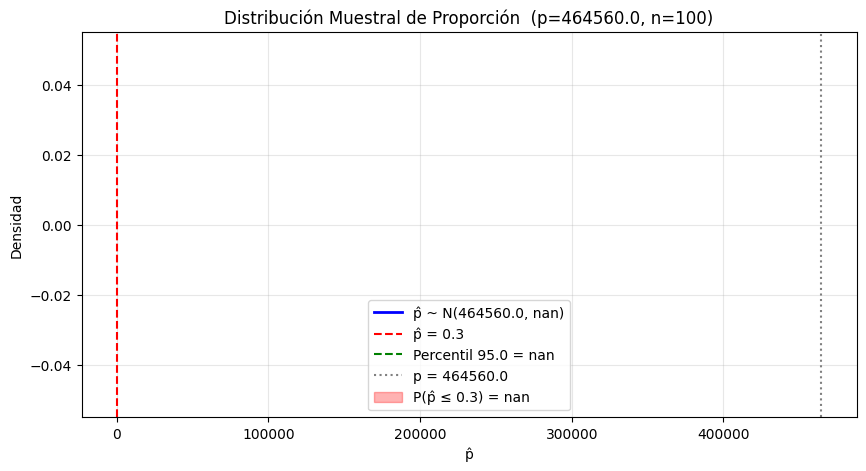

In [6]:
# ========== PARÁMETROS ==========
p_pob = float(input("Ingresa la proporción poblacional (p): "))
n = int(input("Ingresa el tamaño de la muestra (n): "))
p_hat = float(input("Ingresa el valor de p̂ (proporción muestral observada): "))
p_percentil = float(input("Ingresa el percentil que deseas calcular: "))


# ========== CÁLCULOS ==========
# Validación de condiciones del TLC
if n * p_pob < 5 or n * (1 - p_pob) < 5:
    print("⚠ Advertencia: las condiciones np ≥ 5 y n(1-p) ≥ 5 no se cumplen.")
    print("  La aproximación normal puede no ser confiable.\n")

error_estandar = np.sqrt(p_pob * (1 - p_pob) / n)
z_valor = (p_hat - p_pob) / error_estandar

print(f"Distribución Muestral de Proporción (p={p_pob}, n={n})\n")
print(f"Media de p̂:          μ_p̂ = {p_pob:.6f}")
print(f"Error estándar:       σ_p̂ = √(p·(1-p)/n) = {error_estandar:.6f}")
print(f"Valor estandarizado:  z   = (p̂ - p) / σ_p̂ = {z_valor:.4f}")

# Probabilidades
prob_menor = stats.norm.cdf(p_hat, loc=p_pob, scale=error_estandar)
prob_mayor = stats.norm.sf(p_hat, loc=p_pob, scale=error_estandar)

print(f"\nP(p̂ ≤ {p_hat}) = {prob_menor:.6f}")
print(f"P(p̂ > {p_hat}) = {prob_mayor:.6f}")

# Percentil
ppf_val = stats.norm.ppf(p_percentil, loc=p_pob, scale=error_estandar)
print(f"\nValor crítico para P(p̂ ≤ x) = {p_percentil}: x = {ppf_val:.6f}")

# Gráfico
rango = 4 * error_estandar
p_vals = np.linspace(p_pob - rango, p_pob + rango, 300)
densidades = stats.norm.pdf(p_vals, loc=p_pob, scale=error_estandar)

plt.figure(figsize=(10, 5))
plt.plot(p_vals, densidades, 'b-', linewidth=2, label=f'p̂ ~ N({p_pob}, {error_estandar:.4f})')
plt.axvline(p_hat, color='r', linestyle='--', label=f'p̂ = {p_hat}')
plt.axvline(ppf_val, color='g', linestyle='--', label=f'Percentil {p_percentil} = {ppf_val:.4f}')
plt.axvline(p_pob, color='gray', linestyle=':', linewidth=1.5, label=f'p = {p_pob}')
plt.fill_between(p_vals, 0, densidades, where=(p_vals <= p_hat), alpha=0.3, color='red',
                 label=f'P(p̂ ≤ {p_hat}) = {prob_menor:.4f}')
plt.xlabel('p̂')
plt.ylabel('Densidad')
plt.title(f'Distribución Muestral de Proporción  (p={p_pob}, n={n})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Estimación Puntual

---

In [1]:
# ========== PARÁMETROS ==========
print("Ingresa los datos de la muestra separados por comas (ej: 76, 68, 85, 56, 65):")
datos_raw = input("Datos: ")
muestra = np.array([float(x.strip()) for x in datos_raw.split(',')])

# Para la proporción muestral
calcular_prop = input("¿Calcular proporción muestral p̄? (s/n): ").strip().lower()
if calcular_prop == 's':
    exitos = int(input(f"  Ingresa el número de éxitos (de {len(muestra)} observaciones): "))

# ========== CÁLCULOS ==========
n = len(muestra)
xbarra = np.mean(muestra)
s2 = np.var(muestra, ddof=1)
s = np.std(muestra, ddof=1)

print(f"\nEstimación Puntual  (n = {n})\n")
print(f"{'Parámetro poblacional':<30} {'Estimador puntual':<25} {'Estimación'}")
print("-" * 70)
print(f"{'μ  (media poblacional)':<30} {'x̄  (media muestral)':<25} {xbarra:.4f}")
print(f"{'σ² (varianza poblacional)':<30} {'s² (varianza muestral)':<25} {s2:.4f}")
print(f"{'σ  (desv. estándar pob.)':<30} {'s  (desv. estándar muestral)':<25} {s:.4f}")
if calcular_prop == 's':
    p_barra = exitos / n
    print(f"{'p  (proporción poblacional)':<30} {'p̄  (proporción muestral)':<25} {p_barra:.4f}")

print(f"\nDatos de la muestra: {list(muestra)}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(muestra, bins='auto', edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(xbarra, color='r', linestyle='--', linewidth=2, label=f'x̄ = {xbarra:.2f}')
axes[0].set_xlabel('Valores')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma de la muestra')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(muestra, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].axhline(xbarra, color='r', linestyle='--', linewidth=2, label=f'x̄ = {xbarra:.2f}')
axes[1].set_ylabel('Valores')
axes[1].set_title('Diagrama de caja de la muestra')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ingresa los datos de la muestra separados por comas (ej: 76, 68, 85, 56, 65):


NameError: name 'np' is not defined

## 12. Intervalos de Confianza

---

Los intervalos de confianza nos permiten estimar un parámetro poblacional con un nivel de certeza específico.

### 12.1 Intervalo de Confianza para la Media (σ conocida)

In [ ]:
# ========== PARÁMETROS ==========
x_barra = 51800  # Media muestral
sigma = 4000     # Desviación estándar poblacional (conocida)
n = 30           # Tamaño de muestra
confianza = 0.95 # Nivel de confianza (95%)

In [ ]:
# ========== CÁLCULOS ==========
print(f"Intervalo de Confianza para la Media (σ conocida)\n")
print(f"Datos:")
print(f"  Media muestral (x̄): ${x_barra:,.2f}")
print(f"  Desviación estándar poblacional (σ): ${sigma:,.2f}")
print(f"  Tamaño de muestra (n): {n}")
print(f"  Nivel de confianza: {confianza*100}%\n")

# Calcular z crítico
alpha = 1 - confianza
z_critico = stats.norm.ppf(1 - alpha/2)

# Error estándar
error_estandar = sigma / np.sqrt(n)

# Margen de error
margen_error = z_critico * error_estandar

# Intervalo de confianza
ic_inferior = x_barra - margen_error
ic_superior = x_barra + margen_error

print(f"Cálculos:")
print(f"  α = 1 - {confianza} = {alpha}")
print(f"  z_(α/2) = z_({alpha/2}) = {z_critico:.4f}")
print(f"  Error estándar = σ/√n = {sigma}/√{n} = ${error_estandar:.2f}")
print(f"  Margen de error = z × SE = {z_critico:.4f} × ${error_estandar:.2f} = ${margen_error:.2f}\n")

print(f"Resultado:")
print(f"  IC {confianza*100}%: [${ic_inferior:,.2f}, ${ic_superior:,.2f}]\n")
print(f"Interpretación:")
print(f"  Estamos {confianza*100}% seguros de que la media poblacional")
print(f"  está entre ${ic_inferior:,.2f} y ${ic_superior:,.2f}")

# Gráfico
x = np.linspace(x_barra - 4*error_estandar, x_barra + 4*error_estandar, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.norm.pdf(x, loc=x_barra, scale=error_estandar), 'b-', linewidth=2)
plt.axvline(x_barra, color='g', linestyle='-', linewidth=2, label=f'x̄ = ${x_barra:,.0f}')
plt.axvline(ic_inferior, color='r', linestyle='--', linewidth=2, label=f'IC inferior')
plt.axvline(ic_superior, color='r', linestyle='--', linewidth=2, label=f'IC superior')
plt.fill_between(x, 0, stats.norm.pdf(x, loc=x_barra, scale=error_estandar),
                 where=(x >= ic_inferior) & (x <= ic_superior),
                 alpha=0.3, color='red', label=f'IC {confianza*100}%')
plt.xlabel('Media')
plt.ylabel('Densidad')
plt.title(f'Intervalo de Confianza {confianza*100}% para la Media (σ conocida)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12.2 Intervalo de Confianza para la Media (σ desconocida — Distribución t)

In [ ]:
# ========== PARÁMETROS ==========
x_barra = 51800  # Media muestral
s = 4200         # Desviación estándar MUESTRAL (desconocida σ)
n = 30           # Tamaño de muestra
confianza = 0.95 # Nivel de confianza (95%)

In [ ]:
# ========== CÁLCULOS ==========
print(f"Intervalo de Confianza para la Media (σ desconocida)\n")
print(f"Datos:")
print(f"  Media muestral (x̄): ${x_barra:,.2f}")
print(f"  Desviación estándar muestral (s): ${s:,.2f}")
print(f"  Tamaño de muestra (n): {n}")
print(f"  Nivel de confianza: {confianza*100}%\n")

# Calcular t crítico
alpha = 1 - confianza
gl = n - 1  # Grados de libertad
t_critico = stats.t.ppf(1 - alpha/2, df=gl)

# Error estándar
error_estandar = s / np.sqrt(n)

# Margen de error
margen_error = t_critico * error_estandar

# Intervalo de confianza
ic_inferior = x_barra - margen_error
ic_superior = x_barra + margen_error

print(f"Cálculos:")
print(f"  α = 1 - {confianza} = {alpha}")
print(f"  Grados de libertad = n - 1 = {gl}")
print(f"  t_(α/2, {gl}) = {t_critico:.4f}")
print(f"  Error estándar = s/√n = {s}/√{n} = ${error_estandar:.2f}")
print(f"  Margen de error = t × SE = {t_critico:.4f} × ${error_estandar:.2f} = ${margen_error:.2f}\n")

print(f"Resultado:")
print(f"  IC {confianza*100}%: [${ic_inferior:,.2f}, ${ic_superior:,.2f}]\n")
print(f"Interpretación:")
print(f"  Estamos {confianza*100}% seguros de que la media poblacional")
print(f"  está entre ${ic_inferior:,.2f} y ${ic_superior:,.2f}")

# Gráfico comparativo t vs normal
x = np.linspace(x_barra - 4*error_estandar, x_barra + 4*error_estandar, 300)
plt.figure(figsize=(10, 5))
plt.plot(x, stats.t.pdf((x-x_barra)/error_estandar, df=gl)/error_estandar, 
         'b-', linewidth=2, label=f't(df={gl})')
plt.plot(x, stats.norm.pdf(x, loc=x_barra, scale=error_estandar), 
         'g--', linewidth=1, alpha=0.7, label='Normal')
plt.axvline(x_barra, color='orange', linestyle='-', linewidth=2, label=f'x̄ = ${x_barra:,.0f}')
plt.axvline(ic_inferior, color='r', linestyle='--', linewidth=2)
plt.axvline(ic_superior, color='r', linestyle='--', linewidth=2)
plt.fill_between(x, 0, stats.t.pdf((x-x_barra)/error_estandar, df=gl)/error_estandar,
                 where=(x >= ic_inferior) & (x <= ic_superior),
                 alpha=0.3, color='red', label=f'IC {confianza*100}%')
plt.xlabel('Media')
plt.ylabel('Densidad')
plt.title(f'Intervalo de Confianza {confianza*100}% para la Media (σ desconocida)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12.3 Intervalo de Confianza para una Proporción

In [ ]:
# ========== PARÁMETROS ==========
x = 130          # Número de éxitos
n = 200          # Tamaño de muestra
confianza = 0.95 # Nivel de confianza (95%)

In [ ]:
# ========== CÁLCULOS ==========
print(f"Intervalo de Confianza para una Proporción\n")

# Proporción muestral
p_hat = x / n

print(f"Datos:")
print(f"  Número de éxitos (x): {x}")
print(f"  Tamaño de muestra (n): {n}")
print(f"  Proporción muestral (p̂): {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"  Nivel de confianza: {confianza*100}%\n")

# z crítico
alpha = 1 - confianza
z_critico = stats.norm.ppf(1 - alpha/2)

# Error estándar
error_estandar = np.sqrt(p_hat * (1 - p_hat) / n)

# Margen de error
margen_error = z_critico * error_estandar

# Intervalo de confianza
ic_inferior = max(0, p_hat - margen_error)  # No puede ser negativo
ic_superior = min(1, p_hat + margen_error)  # No puede ser mayor a 1

print(f"Cálculos:")
print(f"  z_(α/2) = {z_critico:.4f}")
print(f"  Error estándar = √[p̂(1-p̂)/n] = {error_estandar:.6f}")
print(f"  Margen de error = z × SE = {margen_error:.6f}\n")

print(f"Resultado:")
print(f"  IC {confianza*100}%: [{ic_inferior:.4f}, {ic_superior:.4f}]")
print(f"  IC {confianza*100}%: [{ic_inferior*100:.2f}%, {ic_superior*100:.2f}%]\n")
print(f"Interpretación:")
print(f"  Estamos {confianza*100}% seguros de que la proporción poblacional")
print(f"  está entre {ic_inferior*100:.2f}% y {ic_superior*100:.2f}%")

# Gráfico
p_vals = np.linspace(max(0, p_hat - 4*error_estandar), 
                     min(1, p_hat + 4*error_estandar), 300)
plt.figure(figsize=(10, 5))
plt.plot(p_vals, stats.norm.pdf(p_vals, loc=p_hat, scale=error_estandar), 
         'b-', linewidth=2)
plt.axvline(p_hat, color='g', linestyle='-', linewidth=2, label=f'p̂ = {p_hat:.4f}')
plt.axvline(ic_inferior, color='r', linestyle='--', linewidth=2)
plt.axvline(ic_superior, color='r', linestyle='--', linewidth=2)
plt.fill_between(p_vals, 0, stats.norm.pdf(p_vals, loc=p_hat, scale=error_estandar),
                 where=(p_vals >= ic_inferior) & (p_vals <= ic_superior),
                 alpha=0.3, color='red', label=f'IC {confianza*100}%')
plt.xlabel('Proporción')
plt.ylabel('Densidad')
plt.title(f'Intervalo de Confianza {confianza*100}% para una Proporción')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12.4 Intervalo de Confianza para la Diferencia de Dos Medias Poblacionales

Permite comparar dos poblaciones estimando la diferencia μ₁ − μ₂ con un nivel de confianza dado.
Se consideran tres casos:
- **Caso 1:** Varianzas poblacionales **conocidas** → distribución z
- **Caso 2:** Varianzas desconocidas pero **iguales** (σ₁² = σ₂²) → distribución t con varianza agrupada (*pooled*)
- **Caso 3:** Varianzas desconocidas y **diferentes** (σ₁² ≠ σ₂²) → distribución t de Welch (Satterthwaite)

In [ ]:
# ========== PARÁMETROS ==========
# Selecciona el caso:
#   1 → varianzas CONOCIDAS (usa z)
#   2 → varianzas desconocidas e IGUALES (usa t, pooled)
#   3 → varianzas desconocidas y DIFERENTES (usa t de Welch)
caso = 1

x_barra1 = 75.4   # Media muestral del grupo 1
n1       = 40     # Tamaño de muestra del grupo 1

x_barra2 = 71.2   # Media muestral del grupo 2
n2       = 35     # Tamaño de muestra del grupo 2

confianza = 0.95  # Nivel de confianza

# --- Caso 1: varianzas CONOCIDAS ---
sigma1 = 8.0      # Desviación estándar POBLACIONAL del grupo 1
sigma2 = 7.5      # Desviación estándar POBLACIONAL del grupo 2

# --- Casos 2 y 3: varianzas DESCONOCIDAS ---
s1 = 8.2          # Desviación estándar MUESTRAL del grupo 1
s2 = 7.8          # Desviación estándar MUESTRAL del grupo 2

In [ ]:
# ========== CÁLCULOS ==========
alpha = 1 - confianza
diff  = x_barra1 - x_barra2

if caso == 1:
    # ── Caso 1: σ₁ y σ₂ conocidas ──────────────────────────────────────────
    se      = np.sqrt(sigma1**2 / n1 + sigma2**2 / n2)
    z_crit  = stats.norm.ppf(1 - alpha / 2)
    margen  = z_crit * se
    ic_inf  = diff - margen
    ic_sup  = diff + margen

    print('Intervalo de Confianza para μ₁ − μ₂  (varianzas CONOCIDAS)\n')
    print(f'  x̄₁ = {x_barra1},  σ₁ = {sigma1},  n₁ = {n1}')
    print(f'  x̄₂ = {x_barra2},  σ₂ = {sigma2},  n₂ = {n2}')
    print(f'  Nivel de confianza: {confianza*100:.0f}%\n')
    print(f'  x̄₁ − x̄₂ = {diff:.4f}')
    print(f'  Error estándar = √(σ₁²/n₁ + σ₂²/n₂) = {se:.4f}')
    print(f'  z_(α/2) = {z_crit:.4f}')
    print(f'  Margen de error E = z · SE = {margen:.4f}')
    print(f'\n  IC {confianza*100:.0f}%:  [{ic_inf:.4f} , {ic_sup:.4f}]')
    print(f'\n  Interpretación:')
    cero_dentro = ic_inf <= 0 <= ic_sup
    print(f'  El 0 {'SÍ' if cero_dentro else 'NO'} está dentro del IC '
          f'→ las medias {'podrían ser iguales' if cero_dentro else 'son significativamente diferentes'}.')
    dist_label = f'z  (σ conocidas)'
    x_plot = np.linspace(diff - 4*se, diff + 4*se, 400)
    y_plot = stats.norm.pdf(x_plot, loc=diff, scale=se)

elif caso == 2:
    # ── Caso 2: varianzas desconocidas IGUALES (pooled) ─────────────────────
    gl     = n1 + n2 - 2
    sp2    = ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / gl
    sp     = np.sqrt(sp2)
    se     = sp * np.sqrt(1/n1 + 1/n2)
    t_crit = stats.t.ppf(1 - alpha / 2, df=gl)
    margen = t_crit * se
    ic_inf = diff - margen
    ic_sup = diff + margen

    print('Intervalo de Confianza para μ₁ − μ₂  (varianzas desconocidas IGUALES)\n')
    print(f'  x̄₁ = {x_barra1},  s₁ = {s1},  n₁ = {n1}')
    print(f'  x̄₂ = {x_barra2},  s₂ = {s2},  n₂ = {n2}')
    print(f'  Nivel de confianza: {confianza*100:.0f}%\n')
    print(f'  x̄₁ − x̄₂ = {diff:.4f}')
    print(f'  Varianza agrupada sp² = [(n₁-1)s₁² + (n₂-1)s₂²] / (n₁+n₂-2) = {sp2:.4f}')
    print(f'  sp = {sp:.4f}')
    print(f'  Error estándar = sp · √(1/n₁ + 1/n₂) = {se:.4f}')
    print(f'  Grados de libertad gl = n₁ + n₂ − 2 = {gl}')
    print(f'  t_(α/2, {gl}) = {t_crit:.4f}')
    print(f'  Margen de error E = t · SE = {margen:.4f}')
    print(f'\n  IC {confianza*100:.0f}%:  [{ic_inf:.4f} , {ic_sup:.4f}]')
    cero_dentro = ic_inf <= 0 <= ic_sup
    print(f'\n  El 0 {'SÍ' if cero_dentro else 'NO'} está dentro del IC '
          f'→ las medias {'podrían ser iguales' if cero_dentro else 'son significativamente diferentes'}.')
    dist_label = f't (gl={gl}, pooled)'
    x_plot = np.linspace(diff - 4*se, diff + 4*se, 400)
    y_plot = stats.t.pdf((x_plot - diff) / se, df=gl) / se

elif caso == 3:
    # ── Caso 3: varianzas desconocidas DIFERENTES (Welch) ───────────────────
    se     = np.sqrt(s1**2 / n1 + s2**2 / n2)
    num    = (s1**2/n1 + s2**2/n2)**2
    den    = (s1**2/n1)**2 / (n1 - 1) + (s2**2/n2)**2 / (n2 - 1)
    gl     = num / den                          # grados de libertad de Welch
    t_crit = stats.t.ppf(1 - alpha / 2, df=gl)
    margen = t_crit * se
    ic_inf = diff - margen
    ic_sup = diff + margen

    print('Intervalo de Confianza para μ₁ − μ₂  (varianzas desconocidas DIFERENTES — Welch)\n')
    print(f'  x̄₁ = {x_barra1},  s₁ = {s1},  n₁ = {n1}')
    print(f'  x̄₂ = {x_barra2},  s₂ = {s2},  n₂ = {n2}')
    print(f'  Nivel de confianza: {confianza*100:.0f}%\n')
    print(f'  x̄₁ − x̄₂ = {diff:.4f}')
    print(f'  Error estándar = √(s₁²/n₁ + s₂²/n₂) = {se:.4f}')
    print(f'  Grados de libertad de Welch (Satterthwaite) = {gl:.2f}')
    print(f'  t_(α/2, {gl:.2f}) = {t_crit:.4f}')
    print(f'  Margen de error E = t · SE = {margen:.4f}')
    print(f'\n  IC {confianza*100:.0f}%:  [{ic_inf:.4f} , {ic_sup:.4f}]')
    cero_dentro = ic_inf <= 0 <= ic_sup
    print(f'\n  El 0 {'SÍ' if cero_dentro else 'NO'} está dentro del IC '
          f'→ las medias {'podrían ser iguales' if cero_dentro else 'son significativamente diferentes'}.')
    dist_label = f't de Welch (gl≈{gl:.1f})'
    x_plot = np.linspace(diff - 4*se, diff + 4*se, 400)
    y_plot = stats.t.pdf((x_plot - diff) / se, df=gl) / se

# ── Gráfico ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_plot, y_plot, 'b-', linewidth=2, label=dist_label)
ax.fill_between(x_plot, 0, y_plot,
                where=(x_plot >= ic_inf) & (x_plot <= ic_sup),
                alpha=0.35, color='green', label=f'IC {confianza*100:.0f}%')
ax.axvline(diff,   color='r',      linestyle='--', linewidth=2,
           label=f'x̄₁ − x̄₂ = {diff:.4f}')
ax.axvline(ic_inf, color='orange', linestyle=':',  linewidth=1.5,
           label=f'Límite inf = {ic_inf:.4f}')
ax.axvline(ic_sup, color='orange', linestyle=':',  linewidth=1.5,
           label=f'Límite sup = {ic_sup:.4f}')
ax.axvline(0,      color='gray',   linestyle='-',  linewidth=1,
           label='0  (μ₁ = μ₂)')
ax.set_xlabel('μ₁ − μ₂')
ax.set_ylabel('Densidad')
ax.set_title(f'IC {confianza*100:.0f}% para la Diferencia de Dos Medias  (Caso {caso})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 12.5 Comparación de Niveles de Confianza

In [ ]:
# ========== PARÁMETROS ==========
x_barra = 51800  # Media muestral
sigma = 4000     # Desviación estándar poblacional
n = 30           # Tamaño de muestra

In [ ]:
# ========== CÁLCULOS ==========
print(f"Comparación de Intervalos de Confianza\n")
print(f"Media muestral: ${x_barra:,.2f}")
print(f"σ = ${sigma:,.2f}, n = {n}\n")

error_estandar = sigma / np.sqrt(n)
niveles_confianza = [0.90, 0.95, 0.99]
colores = ['blue', 'green', 'red']

plt.figure(figsize=(12, 6))
x = np.linspace(x_barra - 4*error_estandar, x_barra + 4*error_estandar, 300)
plt.plot(x, stats.norm.pdf(x, loc=x_barra, scale=error_estandar), 
         'k-', linewidth=2, label='Distribución muestral')
plt.axvline(x_barra, color='black', linestyle='-', linewidth=2, label=f'x̄ = ${x_barra:,.0f}')

print("Nivel    z crítico    Margen Error    Intervalo de Confianza")
print("="*70)

for i, conf in enumerate(niveles_confianza):
    alpha = 1 - conf
    z_crit = stats.norm.ppf(1 - alpha/2)
    margen = z_crit * error_estandar
    ic_inf = x_barra - margen
    ic_sup = x_barra + margen
    
    print(f"{conf*100:5.0f}%    {z_crit:8.4f}    ${margen:10,.2f}    [${ic_inf:,.2f}, ${ic_sup:,.2f}]")
    
    plt.fill_between(x, 0, stats.norm.pdf(x, loc=x_barra, scale=error_estandar),
                     where=(x >= ic_inf) & (x <= ic_sup),
                     alpha=0.2, color=colores[i], 
                     label=f'IC {conf*100:.0f}%: [{ic_inf:,.0f}, {ic_sup:,.0f}]')
    plt.axvline(ic_inf, color=colores[i], linestyle='--', linewidth=1.5, alpha=0.7)
    plt.axvline(ic_sup, color=colores[i], linestyle='--', linewidth=1.5, alpha=0.7)

plt.xlabel('Media')
plt.ylabel('Densidad')
plt.title('Comparación de Intervalos de Confianza (90%, 95%, 99%)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservación: A mayor nivel de confianza, mayor es el intervalo.")